In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import warnings

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score

# Data Cleaning and Understanding

In [2]:
df = pd.read_csv('data/dauerzaehlstellen.csv', sep=';', encoding='latin-1')
df.head()

,JAHR,MONAT,ZNR,ZNAME,STRTYP,STRNR,RINAME,FZTYP,DTVMS,DTVMF,DTVMO,DTVDD,DTVFR,DTVSA,DTVSF,TVMAX,TVMAXT
0,2025,MÄRZ,1075,Reichsbrücke,B,8,Leopoldstadt,Kfz,26977,28544,28550,28126,29791,24767,22602,47760,"Do,27.03."
1,2025,MÄRZ,1075,Reichsbrücke,B,8,Leopoldstadt,LkwÄ,1674,1688,1846,1590,1782,1657,1634,5081,"So,30.03."
2,2025,MÄRZ,1075,Reichsbrücke,B,8,Donaustadt,Kfz,16067,17416,16563,17705,17615,14382,12089,19871,"Do,20.03."
3,2025,MÄRZ,1075,Reichsbrücke,B,8,Donaustadt,LkwÄ,282,365,371,381,310,121,96,462,"Di,25.03."
4,2025,MÄRZ,1075,Reichsbrücke,B,8,Gesamt,Kfz,43044,45960,45112,45831,47406,39150,34691,66394,"Do,27.03."


## Drop columns and rows not needed for the analysis

- `ZNR` and `ZNAME` identify the measurement station, with one being an int and the other a string. The columns are redundant, so drop `ZNAME`.
- Keep only `DTVMS` and drop the rest of the traffic count columns since only interested in the average, daily traffic counts for all days of the week.
- Select rows where `FZTYP` == `Kfz` since only want to work with total traffic counts, then drop the column.

In [3]:
drop_cols = ['ZNAME', 'DTVMF', 'DTVMO', 'DTVDD', 'DTVFR', 'FZTYP', 'DTVSA', 'DTVSF', 'TVMAX', 'TVMAXT']
df = (df[df['FZTYP'] == 'Kfz']
      .drop(columns=drop_cols)
      )

## Convert MONAT column from string to int

In [4]:
monat_map = {'jan': 1, 'feb' : 2,  'märz': 3,  'april': 4,
             'mai': 5, 'juni': 6,  'juli': 7,  'aug'  : 8,
             'sep': 9, 'okt' : 10, 'nov' : 11, 'dez'  : 12}

df['MONAT'] = (
    df['MONAT'].str.rstrip('.')
    .str.lower()
    .map(monat_map)
)

df.head()

,JAHR,MONAT,ZNR,STRTYP,STRNR,RINAME,DTVMS
0,2025,3,1075,B,8,Leopoldstadt,26977
2,2025,3,1075,B,8,Donaustadt,16067
4,2025,3,1075,B,8,Gesamt,43044
6,2025,3,1078,B,221,Wienzeile,36497
8,2025,3,1078,B,221,Stadthalle,32686


## Convert `ZNR` from int to str, so treated as a categorical column

In [5]:
df['ZNR'] = df['ZNR'].astype(str)

## Check for missing values

In [6]:
df.isnull().sum()

JAHR      0
MONAT     0
ZNR       0
STRTYP    0
STRNR     0
RINAME    0
DTVMS     0
dtype: int64

## Get summary statistics

In [7]:
df.describe()

,JAHR,MONAT,STRNR,DTVMS
count,22836.000000,22836.000000,22836.000000,22836.000000
mean,2020.245665,6.377430,64.335523,12512.686241
std,2.645973,3.487058,98.986129,11024.950135
min,2016.000000,1.000000,0.000000,-29.000000
25%,2018.000000,3.000000,0.000000,6105.000000
50%,2020.000000,6.000000,3.000000,9577.000000
75%,2023.000000,9.000000,221.000000,16214.250000
max,2025.000000,12.000000,230.000000,78250.000000


There seems to be some records with negative values for traffic counts. Report all distinct negative values for `DTVMS`.

In [8]:
df[df['DTVMS'] < 0]['DTVMS'].unique()

array([-29])

The metadata says that records are assigned a value of -29 if no valid measurement was taken. Therefore, drop these records.

In [9]:
df = df[df['DTVMS'] >= 0]

## Create datetime column for plotting

In [10]:
df_plot = df.copy()
df_plot['timestamp'] = df_plot['JAHR'].astype(str) + ' ' + df_plot['MONAT'].astype(str)
df_plot['timestamp'] = pd.to_datetime(df_plot['timestamp'], format='%Y %m')

### Plot `DTVMS` for a given `ZNR` and `RINAME` to determine how the data looks

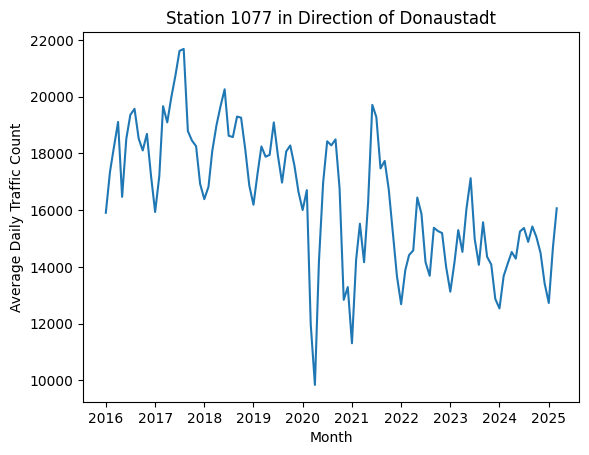

In [11]:
df_slice = df_plot[(df_plot['ZNR'] == '1075') & (df_plot['RINAME'] == 'Donaustadt')]
plt.plot(df_slice['timestamp'], df_slice['DTVMS'])
plt.title('Station 1077 in Direction of Donaustadt')
plt.xlabel('Month')
plt.ylabel('Average Daily Traffic Count')
plt.show()

## Plot histogram of `DTVMS`

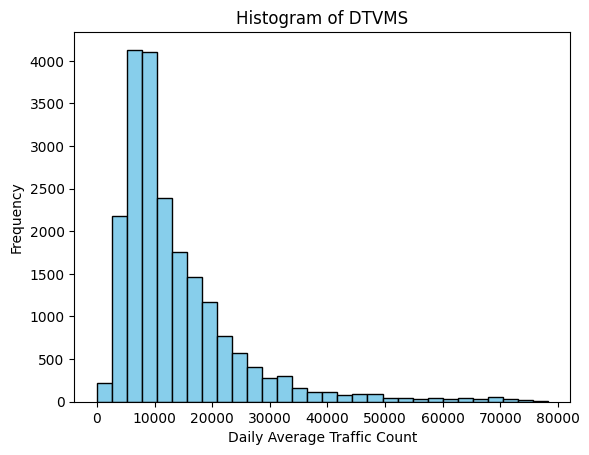

In [12]:
plt.hist(df['DTVMS'], bins=30, color='skyblue', edgecolor='black')

# Adding labels and title
plt.xlabel('Daily Average Traffic Count')
plt.ylabel('Frequency')
plt.title('Histogram of DTVMS')

# Display the plot
plt.show()

# Model Training

## Order data chronologically and split into train and test splits of 80 and 20%

In [13]:
df = (df.sort_values(['JAHR','MONAT'])
      .reset_index(drop=True)
      )
X = df.drop(columns=['DTVMS'])
y = df['DTVMS']
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)

## Apply one-hot encoding to categorical columns

In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["ZNR", "STRTYP", "RINAME"])
    ],
    remainder="passthrough"
)

pipeline = Pipeline([
    ("preprocess", preprocessor),
])

X_train_processed = pipeline.fit_transform(X_train)
X_test_processed  = pipeline.transform(X_test)

## Use grid search on XGBoost regressor

In [15]:
warnings.filterwarnings('ignore') # depreciation warnings

model = xgb.XGBRegressor(objective='reg:squarederror',
                         n_estimators=100, random_state=42)
param_grid = {
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

tscv = TimeSeriesSplit(n_splits=5)
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=tscv, n_jobs=-1, verbose=1)
grid_search.fit(X_train_processed, y_train)

print("Best parameters:", grid_search.best_params_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


/opt/anaconda3/envs/traffic-pred/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/envs/traffic-pred/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/envs/traffic-pred/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using thi

Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 6, 'subsample': 0.8}


## Train best model on train set then apply to test set

In [16]:
model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42,
                         max_depth=6, booster='gbtree',
                         learning_rate=0.2, subsample=0.8, colsample_bytree=0.8)
model.fit(X_train_processed, y_train)
y_pred = model.predict(X_test_processed)

## Get metrics

In [17]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'RMSE: {rmse:.3f}')
print(f'R²: {r2:.3f}')

RMSE: 1447.060
R²: 0.981


## Plot `y_pred` against `y_test`

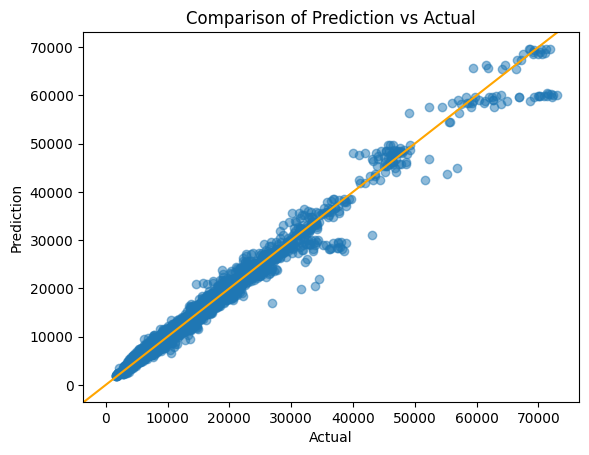

In [18]:
plt.scatter(y_test, y_pred, alpha=0.5)
plt.title('Comparison of Prediction vs Actual')
plt.xlabel('Actual')
plt.ylabel('Prediction')
plt.axline((0, 0), slope=1., color='orange')
plt.show()

## Plot relative error vs index (proxy for time)

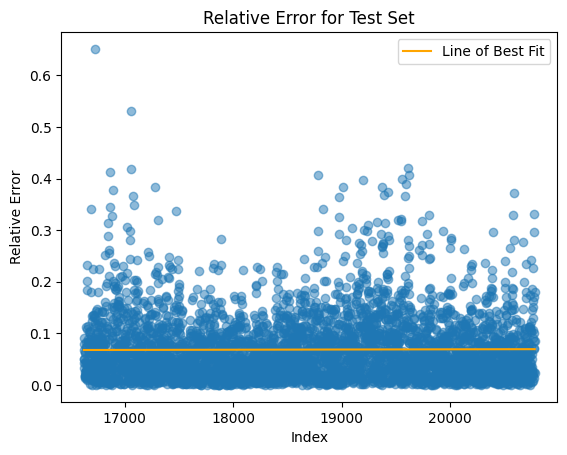

In [22]:
comparison_df = pd.DataFrame({'Actual': y_test, 'Prediction': y_pred})

# cast both columns to floats
comparison_df['Actual'] = comparison_df['Actual'].astype(float)
comparison_df['Prediction'] = comparison_df['Prediction'].astype(float)

comparison_df['Relative Error'] = (comparison_df['Actual'] - comparison_df['Prediction']).abs() / comparison_df['Actual'].abs()

# fit line to datapoints
a, b = np.polyfit(comparison_df.index, comparison_df['Relative Error'], 1)

plt.scatter(comparison_df.index, comparison_df['Relative Error'], alpha=0.5)
plt.plot(comparison_df.index, a*comparison_df.index+b, color='orange', label='Line of Best Fit')
plt.legend(loc='best')
plt.title('Relative Error for Test Set')
plt.xlabel('Index')
plt.ylabel('Relative Error')
plt.show()